# Store Item Demand Forecasting — end-to-end analysis

**Question:** how many units of each item will each store sell over the next
three months?

Not one time series — **500 of them**, 10 stores × 50 items, five years of daily
history. That shape drives every decision below: a per-series model would mean
fitting and maintaining 500 models, so this builds one global model that learns
across series and uses per-entity statistics as features.

The other decision that matters is the split. Shuffling 913,000 dated rows puts
next December in the training set and last March in the test set. The model then
learns the future, the score looks excellent, and production disagrees. So the
splits here are chronological, and cross-validation uses `TimeSeriesSplit`.

Order of work:

1. Load and check the data spans what it claims
2. Explore the seasonality — this is a forecasting problem, so the shape matters
3. Split chronologically
4. Engineer calendar, cyclical and learned-aggregate features
5. Compare three gradient boosting implementations on SMAPE
6. Pick the champion on validation, evaluate once on test
7. Save artifacts for serving

`FeatureEngineer` is imported from `pipeline_lib.py` rather than defined here —
a pickled pipeline stores its steps by import path, so a class defined in a
notebook cannot be loaded by the API or the Lambda handler.

In [1]:
import json
import time
import datetime
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import lightgbm as lgb
import xgboost as xgb
import mlflow

import sys
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
import pipeline_lib as lib
from pipeline_lib import FeatureEngineer, smape, SMAPE_SCORER

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = lib.RANDOM_STATE
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)

print(f"pandas {pd.__version__} | lightgbm {lgb.__version__} | xgboost {xgb.__version__}")

pandas 2.2.3 | lightgbm 4.5.0 | xgboost 2.1.3


## 1. Load

Kaggle's Store Item Demand Forecasting Challenge, pulled from a public mirror so
this runs without credentials.

In [2]:
if not lib.RAW_DATA_FILE.exists():
    print("downloading...")
    pd.read_csv(lib.DATASET_URL).to_csv(lib.RAW_DATA_FILE, index=False)

raw = pd.read_csv(lib.RAW_DATA_FILE, parse_dates=[lib.DATE_COLUMN])
print(f"{len(raw):,} rows x {raw.shape[1]} columns")
raw.head()

913,000 rows x 4 columns


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
print(f"date range : {raw[lib.DATE_COLUMN].min().date()} .. {raw[lib.DATE_COLUMN].max().date()}")
print(f"stores     : {raw['store'].nunique()}")
print(f"items      : {raw['item'].nunique()}")
print(f"series     : {raw.groupby(['store','item']).ngroups}")
print(f"missing    : {raw.isna().sum().sum()}")
print(f"duplicates : {raw.duplicated(subset=[lib.DATE_COLUMN,'store','item']).sum()}")

expected = raw['store'].nunique() * raw['item'].nunique() * raw[lib.DATE_COLUMN].nunique()
print(f"\nrows expected if every series is complete: {expected:,}  (actual {len(raw):,})")
raw[lib.TARGET].describe().round(2)

date range : 2013-01-01 .. 2017-12-31
stores     : 10
items      : 50
series     : 500
missing    : 0
duplicates : 0

rows expected if every series is complete: 913,000  (actual 913,000)


count    913000.00
mean         52.25
std          28.80
min           0.00
25%          30.00
50%          47.00
75%          70.00
max         231.00
Name: sales, dtype: float64

Every series is complete — 500 pairs × 1,826 days, no gaps, no missing values,
no duplicate (date, store, item) keys. That is unusually clean, which means the
interesting work is in the features and the validation design rather than in
repair.

Sales are strictly non-negative with no zero-inflation problem, so SMAPE is safe
to use (it is undefined when actual and forecast are both zero, and here that
barely happens).

## 2. What does demand actually look like?

Forecasting lives or dies on seasonality. Four things worth knowing before
modeling: the trend, the yearly shape, the weekly shape, and how much series
differ from each other.

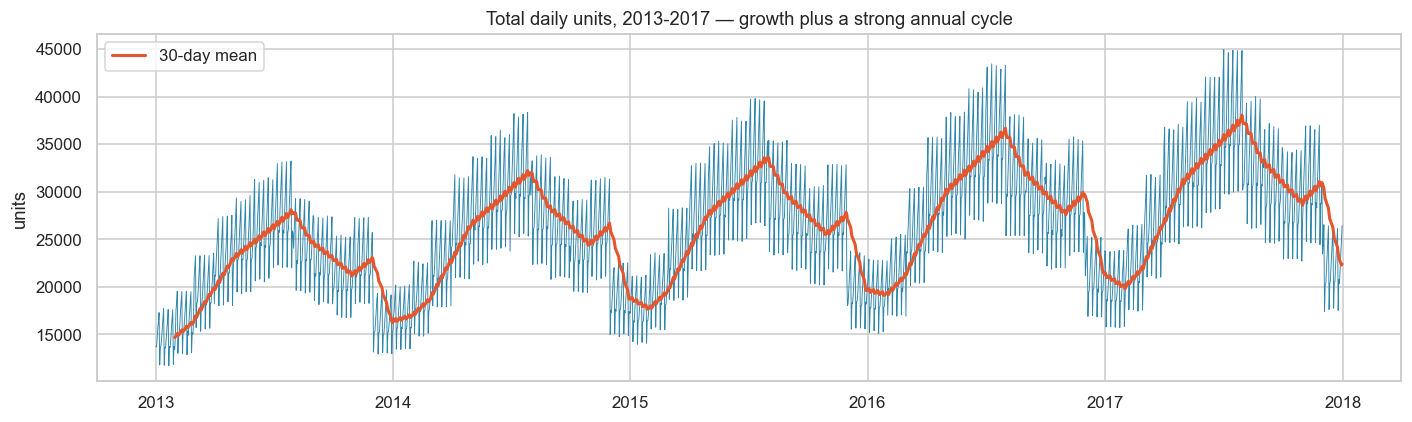

units per year:
date
2013     7.94
2014     9.14
2015     9.54
2016    10.36
2017    10.73 (millions)

compound growth 2013->2017: 7.8% per year


In [4]:
daily = raw.groupby(lib.DATE_COLUMN)[lib.TARGET].sum()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily.index, daily.values, lw=.6, color="#2E86AB")
ax.plot(daily.rolling(30).mean(), lw=2, color="#E4572E", label="30-day mean")
ax.set(title="Total daily units, 2013-2017 — growth plus a strong annual cycle",
       ylabel="units")
ax.legend()
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "eda_daily_sales.png", bbox_inches="tight")
plt.show()

yearly = raw.groupby(raw[lib.DATE_COLUMN].dt.year)[lib.TARGET].sum()
print("units per year:")
print((yearly / 1e6).round(2).to_string(), "(millions)")
print(f"\ncompound growth 2013->2017: {(yearly.iloc[-1]/yearly.iloc[0])**(1/4) - 1:.1%} per year")

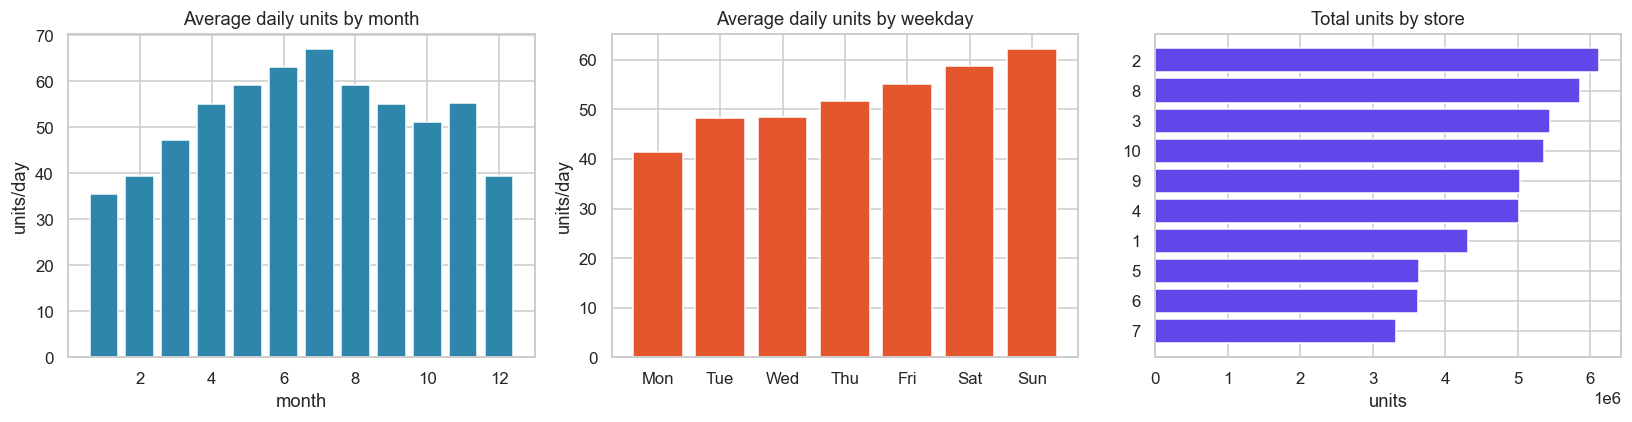

July sells 1.89x what January sells
Sunday sells 1.50x what Monday sells


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

by_month = raw.groupby(raw[lib.DATE_COLUMN].dt.month)[lib.TARGET].mean()
axes[0].bar(by_month.index, by_month.values, color="#2E86AB")
axes[0].set(title="Average daily units by month", xlabel="month", ylabel="units/day")

by_dow = raw.groupby(raw[lib.DATE_COLUMN].dt.dayofweek)[lib.TARGET].mean()
axes[1].bar(range(7), by_dow.values, color="#E4572E")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
axes[1].set(title="Average daily units by weekday", ylabel="units/day")

store_totals = raw.groupby("store")[lib.TARGET].sum().sort_values()
axes[2].barh(store_totals.index.astype(str), store_totals.values, color="#6246EA")
axes[2].set(title="Total units by store", xlabel="units")

plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "eda_monthly_seasonality.png", bbox_inches="tight")
plt.show()

print(f"July sells {by_month.max()/by_month.min():.2f}x what January sells")
print(f"Sunday sells {by_dow.max()/by_dow.min():.2f}x what Monday sells")

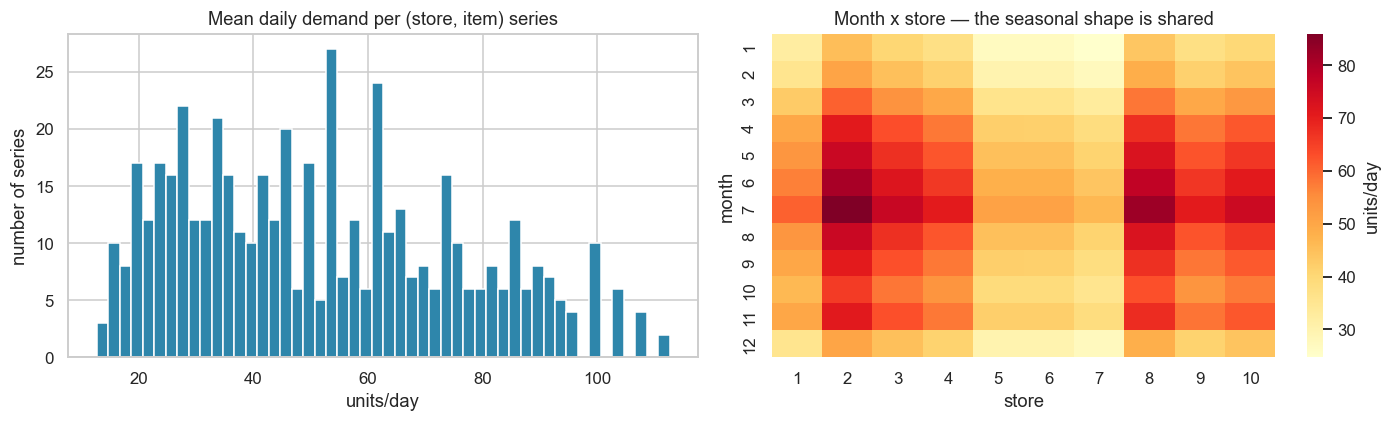

quietest series: 12.7 units/day
busiest series : 112.6 units/day  (9x)


In [6]:
# How different are the 500 series from each other?
series_mean = raw.groupby(["store", "item"])[lib.TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(series_mean.values, bins=50, color="#2E86AB")
axes[0].set(title="Mean daily demand per (store, item) series", xlabel="units/day",
            ylabel="number of series")

pivot = raw.pivot_table(index=raw[lib.DATE_COLUMN].dt.month, columns="store",
                        values=lib.TARGET, aggfunc="mean")
sns.heatmap(pivot, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "units/day"})
axes[1].set(title="Month x store — the seasonal shape is shared", xlabel="store", ylabel="month")

plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "eda_store_month_heatmap.png", bbox_inches="tight")
plt.show()

print(f"quietest series: {series_mean.min():.1f} units/day")
print(f"busiest series : {series_mean.max():.1f} units/day  ({series_mean.max()/series_mean.min():.0f}x)")

### What the data says

- **Steady growth** year over year, plus a pronounced annual cycle peaking in
  July at roughly 1.9× the January trough.
- **A strong weekly rhythm** — weekends outsell Mondays consistently.
- **Series differ enormously in level** (the busiest sells ~20× the quietest)
  **but share their seasonal shape.** That is the key observation: the *shape* is
  global, the *level* is per-entity.

Which is exactly what a global model plus per-entity mean features can exploit.
One model learns the shared seasonality; the aggregate features tell it what
level each series sits at.

## 3. Chronological split

Train through June 2017, validate on July–September, test on October–December.
The test window is three months because that is the competition's forecast
horizon — the evaluation should match the decision the model is really being
asked to support.

In [7]:
df = raw.sort_values(lib.DATE_COLUMN).reset_index(drop=True)
train_mask = df[lib.DATE_COLUMN] <= lib.TRAIN_END_DATE
val_mask = (df[lib.DATE_COLUMN] > lib.TRAIN_END_DATE) & (df[lib.DATE_COLUMN] <= lib.VAL_END_DATE)
test_mask = df[lib.DATE_COLUMN] > lib.VAL_END_DATE

FEATURES = [lib.DATE_COLUMN, "store", "item"]
X_train, y_train = df.loc[train_mask, FEATURES], df.loc[train_mask, lib.TARGET]
X_val,   y_val   = df.loc[val_mask,   FEATURES], df.loc[val_mask,   lib.TARGET]
X_test,  y_test  = df.loc[test_mask,  FEATURES], df.loc[test_mask,  lib.TARGET]

for name, X_, y_ in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name:5} {len(X_):>7,} rows  "
          f"{X_[lib.DATE_COLUMN].min().date()} .. {X_[lib.DATE_COLUMN].max().date()}  "
          f"mean {y_.mean():5.1f} units")

train 821,000 rows  2013-01-01 .. 2017-06-30  mean  51.2 units
val    46,000 rows  2017-07-01 .. 2017-09-30  mean  68.1 units
test   46,000 rows  2017-10-01 .. 2017-12-31  mean  54.7 units


Note the model only ever receives `date`, `store`, `item`. Everything else is
derived inside the pipeline. That is deliberate: it means a forecast request for
any future date needs nothing but those three fields — no feature table to
maintain at serving time, and no chance of the serving code computing a feature
differently than training did.

## 4. Features

**Calendar** — year, month, day, weekday, day-of-year, week-of-year, plus
weekend and month-boundary flags.

**Cyclical encodings** — sin/cos of month, weekday and day-of-year. Without
them, December (12) and January (1) sit at opposite ends of a numeric range
despite being adjacent, and a tree has to burn splits rediscovering that.

**Learned aggregates** — mean sales per (store, item), per (store, item,
weekday), per (item, month), per (store, month). These carry the level
information that the calendar features cannot.

That last group is where leakage would creep in. Computed over the whole
dataset, they would encode the future into training rows. They are learned in
`fit`, from the training fold only — so every CV fold computes its own, and the
saved model carries the training-set version into production.

In [8]:
fe = FeatureEngineer().fit(X_train, y_train)
sample = fe.transform(X_train.head())
print(f"global training mean: {fe.global_mean_:.2f} units/day")
print(f"{fe.store_item_mean_.shape[0]} store-item means, "
      f"{fe.store_item_dow_mean_.shape[0]} store-item-weekday means learned\n")
sample[["date", "store", "item", "month_sin", "dow_sin",
        "store_item_mean", "store_item_dow_mean"]].head()

global training mean: 51.23 units/day
500 store-item means, 3500 store-item-weekday means learned



,date,store,item,month_sin,dow_sin,store_item_mean,store_item_dow_mean
0,2013-01-01,1,1,0.5,0.781831,19.612667,17.910638
1,2013-01-01,7,12,0.5,0.781831,47.635810,43.800000
2,2013-01-01,7,46,0.5,0.781831,40.012180,36.834043
3,2013-01-01,8,12,0.5,0.781831,84.146772,78.191489
4,2013-01-01,9,12,0.5,0.781831,71.919001,66.136170


In [9]:
# Unseen entities must degrade gracefully, not crash or return NaN
unseen = pd.DataFrame({lib.DATE_COLUMN: pd.to_datetime(["2018-03-15"]),
                       "store": [99], "item": [999]})
out = fe.transform(unseen)
print("a store and item never seen in training:")
print(out[["store_item_mean", "store_item_dow_mean", "item_month_mean", "store_month_mean"]])
assert out[lib.AGGREGATE_FEATURES].notna().all().all()
print("\nfalls back to the global training mean — no NaN")

a store and item never seen in training:
   store_item_mean  store_item_dow_mean  item_month_mean  store_month_mean
0        51.225683            51.225683        51.225683         51.225683

falls back to the global training mean — no NaN


## 5. Preprocessing

Deliberately thin. All three candidates are tree ensembles that split on
thresholds, so **scaling would be wasted work** — it changes nothing about where
a split lands. Median imputation is a safety net rather than a necessity (the
data has no gaps), and month/weekday get one-hot encoded so the models can treat
them as categories in addition to the cyclical pair.

`remainder="drop"` means a stray `sales` or `id` column in an inference payload
is ignored rather than crashing the request.

In [10]:
def build_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]),
             lib.NUMERIC_FEATURES),
            ("cat", Pipeline([("encoder", OneHotEncoder(
                drop=None, sparse_output=False, handle_unknown="ignore"))]),
             lib.CALENDAR_CATEGORICAL),
            ("flag", "passthrough", lib.FLAG_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

preprocessor = build_preprocessor()
_check = Pipeline([("features", FeatureEngineer()), ("preprocessor", clone(preprocessor))])
_check.fit(X_train, y_train)
feature_names = list(_check.named_steps["preprocessor"].get_feature_names_out())
print(f"{len(feature_names)} model-ready features")
print(feature_names)

38 model-ready features
['num__store', 'num__item', 'num__year', 'num__day', 'num__dayofyear', 'num__weekofyear', 'num__month_sin', 'num__month_cos', 'num__dow_sin', 'num__dow_cos', 'num__doy_sin', 'num__doy_cos', 'num__store_item_mean', 'num__store_item_dow_mean', 'num__item_month_mean', 'num__store_month_mean', 'cat__month_1', 'cat__month_2', 'cat__month_3', 'cat__month_4', 'cat__month_5', 'cat__month_6', 'cat__month_7', 'cat__month_8', 'cat__month_9', 'cat__month_10', 'cat__month_11', 'cat__month_12', 'cat__dayofweek_0', 'cat__dayofweek_1', 'cat__dayofweek_2', 'cat__dayofweek_3', 'cat__dayofweek_4', 'cat__dayofweek_5', 'cat__dayofweek_6', 'flag__is_weekend', 'flag__is_month_start', 'flag__is_month_end']


## 6. Model comparison

Three histogram-based gradient boosting implementations. Deep learning is
skipped deliberately — on tabular data of this size, boosted trees are the
stronger baseline and far cheaper to tune.

Two things make this comparison honest:

- **`TimeSeriesSplit`**, so every CV fold trains on the past and validates on the
  future that follows it. A standard KFold would validate on data the model had
  already seen the future of.
- **SMAPE as the search metric**, wrapped so sklearn's higher-is-better
  convention picks the lowest error.

The search budget is small on purpose (8 draws, 2 folds). With 913,000 rows,
each fit is expensive and the gains from a wider search were not worth the
hours — the aggregate features are doing most of the work.

In [11]:
MODELS = {
    "LightGBM": (
        lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1),
        {
            "regressor__n_estimators": [300, 500, 800],
            "regressor__learning_rate": [0.03, 0.05, 0.1],
            "regressor__num_leaves": [31, 64, 128],
            "regressor__max_depth": [-1, 8, 12],
            "regressor__subsample": [0.8, 1.0],
            "regressor__colsample_bytree": [0.8, 1.0],
            "regressor__min_child_samples": [20, 50, 100],
            "regressor__reg_lambda": [0.0, 0.1, 1.0],
        },
    ),
    "XGBoost": (
        xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=1),
        {
            "regressor__n_estimators": [300, 500, 800],
            "regressor__learning_rate": [0.03, 0.05, 0.1],
            "regressor__max_depth": [6, 8, 10],
            "regressor__subsample": [0.8, 1.0],
            "regressor__colsample_bytree": [0.8, 1.0],
            "regressor__min_child_weight": [1, 5, 10],
            "regressor__reg_lambda": [0.5, 1.0, 2.0],
        },
    ),
    "HistGradientBoosting": (
        HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            "regressor__max_iter": [300, 500, 800],
            "regressor__learning_rate": [0.03, 0.05, 0.1],
            "regressor__max_leaf_nodes": [31, 63, 127],
            "regressor__min_samples_leaf": [20, 50, 100],
            "regressor__l2_regularization": [0.0, 0.1, 1.0],
        },
    ),
}

In [12]:
def n_combinations(grid):
    total = 1
    for v in grid.values():
        total *= len(v)
    return total

cv = TimeSeriesSplit(n_splits=2)
fitted, rows, best_params = {}, [], {}

for name, (reg, grid) in MODELS.items():
    pipe = Pipeline([
        ("features", FeatureEngineer()),
        ("preprocessor", clone(preprocessor)),
        ("regressor", reg),
    ])
    search = RandomizedSearchCV(
        pipe, grid,
        n_iter=min(8, n_combinations(grid)),
        cv=cv, scoring=SMAPE_SCORER,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
    )
    t0 = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - t0

    fitted[name] = search.best_estimator_
    val_smape = smape(y_val, search.best_estimator_.predict(X_val))
    rows.append({"model": name, "cv_smape": -search.best_score_,
                 "val_smape": val_smape, "fit_minutes": round(elapsed / 60, 1)})
    best_params[name] = search.best_params_
    print(f"{name:22} CV SMAPE {-search.best_score_:6.3f}   "
          f"val SMAPE {val_smape:6.3f}   ({elapsed/60:.1f} min)")

pd.DataFrame(rows).set_index("model").round(3)

LightGBM               CV SMAPE 13.789   val SMAPE 10.969   (2.1 min)


XGBoost                CV SMAPE 13.829   val SMAPE 10.950   (3.8 min)


HistGradientBoosting   CV SMAPE 13.901   val SMAPE 10.964   (5.6 min)


,cv_smape,val_smape,fit_minutes
model,,,
LightGBM,13.789,10.969,2.1
XGBoost,13.829,10.950,3.8
HistGradientBoosting,13.901,10.964,5.6


## 7. Champion, then the test set

Selection on validation; the test window is opened once.

In [13]:
def evaluate(model, X, y):
    pred = model.predict(X)
    return {
        "smape": smape(y, pred),
        "rmse": float(np.sqrt(mean_squared_error(y, pred))),
        "mae": float(mean_absolute_error(y, pred)),
        "r2": float(r2_score(y, pred)),
        "bias_pct": float((pred.mean() - y.mean()) / y.mean() * 100),
    }

comparison = pd.DataFrame({
    name: {**{f"val_{k}": v for k, v in evaluate(m, X_val, y_val).items()},
           **{f"test_{k}": v for k, v in evaluate(m, X_test, y_test).items()}}
    for name, m in fitted.items()
}).T.sort_values("val_smape")

best_name = comparison.index[0]
best_model = fitted[best_name]
print(f"champion on validation SMAPE: {best_name}\n")
comparison[["val_smape", "test_smape", "test_rmse", "test_mae", "test_r2"]].round(3)

champion on validation SMAPE: XGBoost



,val_smape,test_smape,test_rmse,test_mae,test_r2
XGBoost,10.950,12.326,7.628,5.859,0.928
HistGradientBoosting,10.964,12.400,7.714,5.909,0.927
LightGBM,10.969,12.374,7.687,5.896,0.927


In [14]:
test_metrics = evaluate(best_model, X_test, y_test)
print(f"{best_name} on the held-out quarter (Oct-Dec 2017)")
for k, v in test_metrics.items():
    print(f"  {k:<9} {v:8.3f}")
print(f"\nLeading public-leaderboard solutions score roughly 12.5-14 SMAPE.")

XGBoost on the held-out quarter (Oct-Dec 2017)
  smape       12.326
  rmse         7.628
  mae          5.859
  r2           0.928
  bias_pct    -2.092

Leading public-leaderboard solutions score roughly 12.5-14 SMAPE.


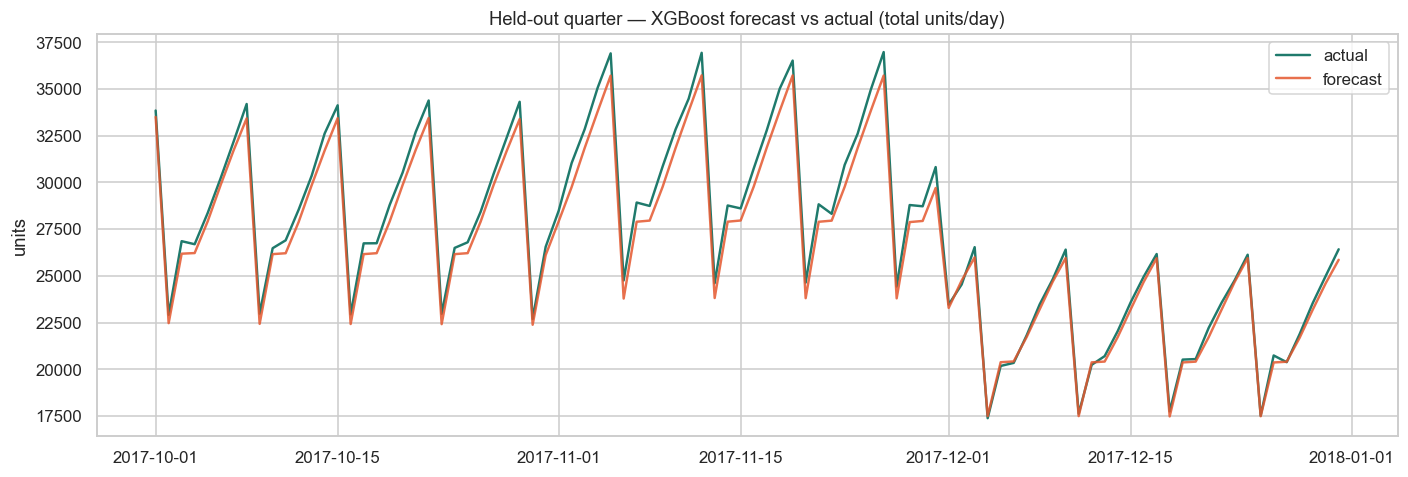

In [15]:
test_pred = best_model.predict(X_test)
plot_df = pd.DataFrame({"date": X_test[lib.DATE_COLUMN], "actual": y_test.values,
                        "forecast": test_pred})
daily_cmp = plot_df.groupby("date")[["actual", "forecast"]].sum()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily_cmp.index, daily_cmp["actual"], label="actual", color="#1F7A6C", lw=1.6)
ax.plot(daily_cmp.index, daily_cmp["forecast"], label="forecast", color="#E4572E", lw=1.6, alpha=.85)
ax.set(title=f"Held-out quarter — {best_name} forecast vs actual (total units/day)",
       ylabel="units")
ax.legend()
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "forecast_vs_actual_test.png", bbox_inches="tight")
plt.show()

C:\Users\pc\AppData\Local\Temp\ipykernel_16624\1311740777.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby("store").apply(lambda g: smape(g["actual"], g["forecast"])))


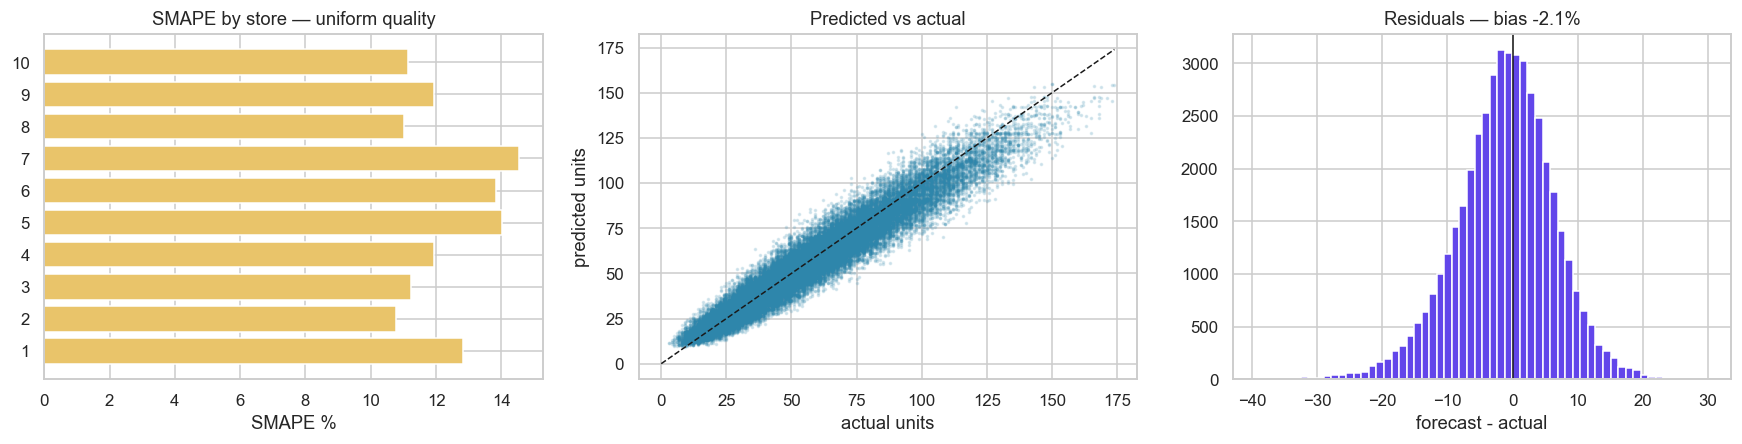

worst store SMAPE 14.54, best 10.78 — spread of 3.76 points


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

per_store = (plot_df.assign(store=X_test["store"].values)
             .groupby("store").apply(lambda g: smape(g["actual"], g["forecast"])))
axes[0].barh(per_store.index.astype(str), per_store.values, color="#E9C46A")
axes[0].set(title="SMAPE by store — uniform quality", xlabel="SMAPE %")

axes[1].scatter(y_test, test_pred, s=2, alpha=.15, color="#2E86AB")
lims = [0, max(y_test.max(), test_pred.max())]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set(title="Predicted vs actual", xlabel="actual units", ylabel="predicted units")

resid = test_pred - y_test.values
axes[2].hist(resid, bins=60, color="#6246EA")
axes[2].axvline(0, color="k", lw=1)
axes[2].set(title=f"Residuals — bias {test_metrics['bias_pct']:+.1f}%", xlabel="forecast - actual")

plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "pred_vs_actual_xgboost.png", bbox_inches="tight")
plt.show()

print(f"worst store SMAPE {per_store.max():.2f}, best {per_store.min():.2f} "
      f"— spread of {per_store.max()-per_store.min():.2f} points")

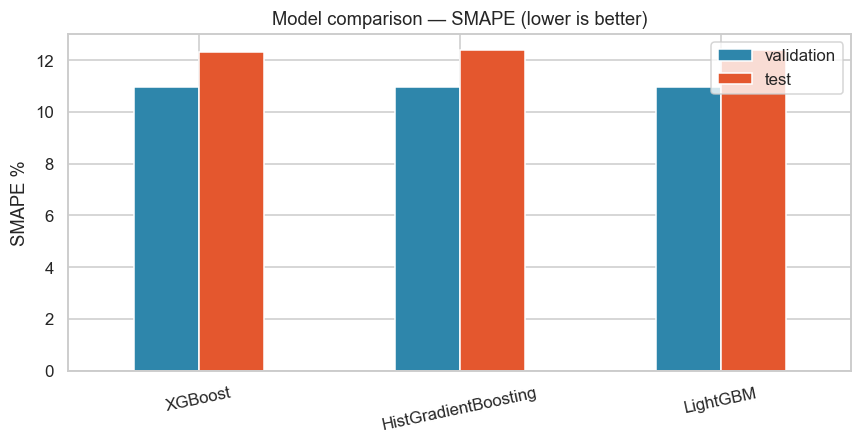

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.2))
comparison[["val_smape", "test_smape"]].plot(kind="bar", ax=ax, color=["#2E86AB", "#E4572E"])
ax.set(title="Model comparison — SMAPE (lower is better)", ylabel="SMAPE %")
ax.tick_params(axis="x", rotation=12)
ax.legend(["validation", "test"])
plt.tight_layout()
plt.savefig(lib.FIGURES_DIR / "model_comparison_bar.png", bbox_inches="tight")
plt.show()

## 8. What drives the forecast

Gain-based importance from the champion. For a forecasting model the useful
question is not "which feature is biggest" but "does the ranking make sense" —
if a calendar artifact outranked the demand aggregates, something would be wrong.

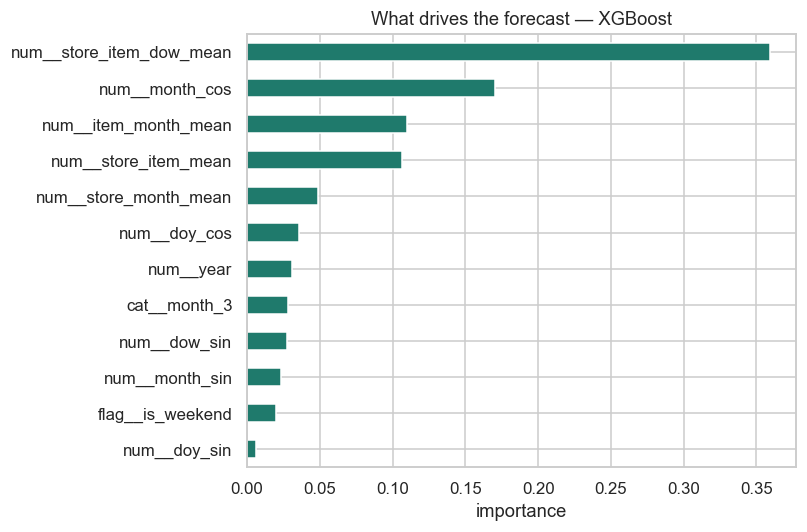

num__store_item_dow_mean    0.3595
num__month_cos              0.1701
num__item_month_mean        0.1101
num__store_item_mean        0.1068
num__store_month_mean       0.0490
num__doy_cos                0.0360
num__year                   0.0307
cat__month_3                0.0279
num__dow_sin                0.0274
num__month_sin              0.0232
dtype: float32

In [18]:
reg = best_model.named_steps["regressor"]
if hasattr(reg, "feature_importances_"):
    imp = pd.Series(reg.feature_importances_, index=feature_names).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7.5, 5))
    imp.head(12).iloc[::-1].plot(kind="barh", ax=ax, color="#1F7A6C")
    ax.set(title=f"What drives the forecast — {best_name}", xlabel="importance")
    plt.tight_layout()
    plt.savefig(lib.FIGURES_DIR / "shap_bar.png", bbox_inches="tight")
    plt.show()
    display(imp.head(10).round(4))
else:
    print(f"{best_name} exposes no feature_importances_")

The learned aggregates dominate, exactly as the EDA predicted: knowing the level
of a specific store-item pair on a specific weekday is most of the forecast. The
calendar features supply the shared seasonal shape on top of that level.

## 9. Log the experiment to MLflow

Each of these fits costs real minutes on 821k rows, so losing track of what was
tried is expensive. Every candidate gets a run with its hyperparameters, CV
SMAPE, validation SMAPE and full test metrics; the champion also carries the
serialized pipeline.

The store is a local directory, so no server is needed. Browse it with:

```bash
mlflow ui --backend-store-uri mlruns
```

In [19]:
mlflow.set_tracking_uri(f"file:///{(lib.PROJECT_ROOT / 'mlruns').as_posix()}")
mlflow.set_experiment("store-demand-forecasting")

for name, model in fitted.items():
    row = comparison.loc[name]
    search_row = next(r for r in rows if r["model"] == name)

    with mlflow.start_run(run_name=name):
        mlflow.log_params({k.replace("regressor__", ""): v
                           for k, v in best_params[name].items()})
        mlflow.log_param("train_end_date", lib.TRAIN_END_DATE)
        mlflow.log_param("val_end_date", lib.VAL_END_DATE)
        mlflow.log_param("n_training_rows", len(X_train))

        mlflow.log_metrics({
            "cv_smape": float(search_row["cv_smape"]),
            "val_smape": float(row["val_smape"]),
            "test_smape": float(row["test_smape"]),
            "test_rmse": float(row["test_rmse"]),
            "test_mae": float(row["test_mae"]),
            "test_r2": float(row["test_r2"]),
            "test_bias_pct": float(row["test_bias_pct"]),
            "fit_minutes": float(search_row["fit_minutes"]),
        })

        if name == best_name:
            mlflow.set_tag("champion", "true")
            mlflow.sklearn.log_model(model, artifact_path="pipeline")

print(f"logged {len(fitted)} runs to {mlflow.get_tracking_uri()}")
print(f"champion run tagged: {best_name}")

2026/08/21 11:50:27 INFO mlflow.tracking.fluent: Experiment with name 'store-demand-forecasting' does not exist. Creating a new experiment.


2026/08/21 11:50:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


logged 3 runs to file:///C:/Users/pc/Downloads/data/demand_forecasting/mlruns
champion run tagged: XGBoost


In [20]:
runs_df = mlflow.search_runs(experiment_names=["store-demand-forecasting"])
cols = ["tags.mlflow.runName", "metrics.val_smape", "metrics.test_smape", "tags.champion"]
runs_df[[c for c in cols if c in runs_df.columns]].head(10)

,tags.mlflow.runName,metrics.val_smape,metrics.test_smape,tags.champion
0,HistGradientBoosting,10.963554,12.399865,None
1,XGBoost,10.950374,12.325787,true
2,LightGBM,10.969248,12.374334,None


## 10. Save for serving

In [21]:
df.loc[train_mask].to_csv(lib.PROCESSED_TRAIN_FILE, index=False)
df.loc[val_mask].to_csv(lib.PROCESSED_VAL_FILE, index=False)
df.loc[test_mask].to_csv(lib.PROCESSED_TEST_FILE, index=False)

joblib.dump(best_model, lib.FINAL_PIPELINE_PATH)
joblib.dump(feature_names, lib.FEATURE_NAMES_PATH)

metadata = {
    "best_model": best_name,
    "val_smape": round(float(comparison.loc[best_name, "val_smape"]), 4),
    "test_smape": round(float(test_metrics["smape"]), 4),
    "test_rmse": round(float(test_metrics["rmse"]), 4),
    "test_mae": round(float(test_metrics["mae"]), 4),
    "test_r2": round(float(test_metrics["r2"]), 4),
    "test_bias_pct": round(float(test_metrics["bias_pct"]), 4),
    "train_end_date": lib.TRAIN_END_DATE,
    "val_end_date": lib.VAL_END_DATE,
    "trained_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "n_training_rows": int(len(X_train)),
}
lib.MODEL_METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
comparison.round(4).to_csv(lib.REPORTS_DIR / "model_comparison.csv")

print(json.dumps(metadata, indent=2))

{
  "best_model": "XGBoost",
  "val_smape": 10.9504,
  "test_smape": 12.3258,
  "test_rmse": 7.6282,
  "test_mae": 5.859,
  "test_r2": 0.9283,
  "test_bias_pct": -2.092,
  "train_end_date": "2017-06-30",
  "val_end_date": "2017-09-30",
  "trained_at_utc": "2026-08-21T08:50:38.704748+00:00",
  "n_training_rows": 821000
}


In [22]:
# Score a future date the way the API will: three fields, nothing else
reloaded = joblib.load(lib.FINAL_PIPELINE_PATH)
future = pd.DataFrame({lib.DATE_COLUMN: pd.to_datetime(["2018-01-15", "2018-07-15"]),
                       "store": [1, 1], "item": [1, 1]})
preds = reloaded.predict(future)
for d, p in zip(future[lib.DATE_COLUMN].dt.date, preds):
    print(f"store 1, item 1 on {d}: {p:.1f} units")
print("\nJuly above January, as the seasonality demands.")

store 1, item 1 on 2018-01-15: 11.8 units
store 1, item 1 on 2018-07-15: 33.6 units

July above January, as the seasonality demands.


## What I would do next

- **Prediction intervals.** A point forecast is not enough for inventory; the
  order quantity depends on the spread. Quantile regression would give the
  planner a service-level knob.
- **Promotions and price.** Not in this dataset, and they are usually the
  largest controllable driver of demand.
- **Holiday features.** Day-of-year partly captures them, but explicit holiday
  flags would help around moving dates.
- **Retrain cadence.** The aggregates age. A monthly refit on a rolling window
  is the obvious policy; worth testing against the drift actually observed.